# Auto-Zero Amplifier (オートゼロアンプ)

Analog Devices の記事
[Demystifying Auto-Zero Amplifiers — Part 1](https://www.analog.com/jp/resources/analog-dialogue/articles/demystifying-auto-zero-amplifiers-part-1.html)
を参考に、**メインアンプ (Main Amplifier)** と **ナリングアンプ (Nulling Amplifier)** の
2 つのアンプを用いたオートゼロアンプを PySpice + ngspice で設計・検証する。

## 動作原理

オートゼロアンプは、DC オフセット電圧 $V_{OS}$ を連続的に測定して打ち消すことで、
数 µV 以下の入力オフセットを実現する。本ノートブックで構成するのは次の 2 相構成である。

| フェーズ | クロック | ナリングアンプの動作 | 保存先 |
|---|---|---|---|
| Phase A (オートゼロ) | $\phi = H$ | 自身の入力を短絡し、**自分自身のオフセット** $V_{OSN}$ を測定 | $C_N$ |
| Phase B (補正) | $\overline{\phi} = H$ | メインアンプの入力ピン間誤差を測定し、$C_N$ の値で自己オフセットを補正して出力 | $C_M$ |

$C_M$ に蓄えられた電圧はメインアンプの **null 端子** に加えられ、
メインアンプのオフセット $V_{OSM}$ を打ち消す。

### 残留オフセット

ナリングループのゲインを $A_N$ とすると、補正後の等価入力オフセットは概ね

$$V_{OS,\mathrm{eff}} \simeq \frac{V_{OSM}}{1 + A_N}$$

となり、$A_N$ が大きいほどオフセットは小さくなる。
ナリングアンプ自身のオフセット $V_{OSN}$ は Phase A で $C_N$ に取得され差し引かれるため、
原理的には残らない。

## 1. セットアップ

ngspice 42 は `Using ... as Direct Linear Solver` や `Note: ...` といった
無害な情報メッセージを stderr に出力するが、PySpice はこれを一律エラーとみなして
解析を中断してしまう。そこで、無害なメッセージだけだった場合はエラー判定を
取り消すようにパッチを当てる。

In [1]:
from PySpice.Spice.NgSpice.Shared import NgSpiceCommandError, NgSpiceShared
from PySpice.Spice.NgSpice.Simulation import NgSpiceSharedCircuitSimulator

# 無害と判断する stderr メッセージの接頭辞
_BENIGN = ("Using ", "Note:", "Warning:")

_original_exec_command = NgSpiceShared.exec_command


def _exec_command(self, command, join_lines=True):
    try:
        return _original_exec_command(self, command, join_lines)
    except NgSpiceCommandError:
        only_benign = bool(self._stderr) and all(
            (not m.strip()) or m.strip().startswith(_BENIGN) for m in self._stderr
        )
        if self._error_in_stdout or not only_benign:
            raise
        self._error_in_stderr = False
        return self.stdout if join_lines else self._stdout


# ngspice の共有ライブラリは二重ロードできないため、クラスにパッチを当てる
NgSpiceShared.exec_command = _exec_command


class NgSpice42CircuitSimulator(NgSpiceSharedCircuitSimulator):
    """ngspice 42 の情報メッセージによる誤判定を回避するシミュレータ。"""

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# グラフ中の日本語が豆腐にならないようにフォントを設定する
plt.rcParams["font.family"] = ["IPAexGothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# ===== 設計パラメータ =====
VOSM = 5e-3          # メインアンプの入力オフセット [V]
VOSN = 4e-3          # ナリングアンプの入力オフセット [V]
GM = 1e-3            # 各 gm 段の相互コンダクタンス [S]
RO = 1e6             # 出力抵抗 [Ohm] -> 単段ゲイン A = gm*ro = 1000
GM_NULL = 1e-3       # メインアンプ null 入力段の gm [S]
CSTOR = 10e-12       # ストレージコンデンサ C_M, C_N [F]

FAZ = 10e3           # オートゼロクロック [Hz]
TAZ = 1 / FAZ        # オートゼロ周期 [s]

RF, RG = 10e3, 1e3   # 帰還抵抗
GAIN = 1 + RF / RG   # 非反転ゲイン = 11

FSIG = 200.0         # 入力信号周波数 [Hz]
VSIG = 10e-3         # 入力信号振幅 [V]

print(f"クローズドループゲイン       : {GAIN:.0f} V/V")
print(f"単段オープンループゲイン A    : {GM*RO:.0f} V/V")
print(f"ストレージ時定数 RO*C        : {RO*CSTOR*1e6:.1f} us  (フェーズ幅 {TAZ/2*1e6:.0f} us)")

クローズドループゲイン       : 11 V/V
単段オープンループゲイン A    : 1000 V/V
ストレージ時定数 RO*C        : 10.0 us  (フェーズ幅 50 us)


## 2. 回路の構築

ポイントは **ナリングアンプが観測する節点** である。
メインアンプの内部オフセット $V_{OSM}$ は入力に直列な電圧源 `Vosm` で表現しているため、
オフセットを含んだ内部節点 `vinp` を観測してしまうと $V_{OSM}$ が相殺されて見えなくなる。
そのため、ナリングアンプは**外部入力ピン** `vin` と帰還点 `vfb` の間を観測する。

各フェーズの動作はクロック電圧 `v(phi)/5`, `v(phib)/5` を
振る舞い電流源 (`B` 素子) の式に掛けることで表現している。
これによりスイッチ素子を使うよりも収束性が良くなる。

In [3]:
def build_amplifier(auto_zero=True):
    """オートゼロアンプの回路を構築する。

    auto_zero=False のときは null 端子を接地し、補正を無効にした
    素のアンプ (オフセットがそのまま出る) になる。
    """
    circuit = Circuit("Auto-Zero Amplifier")

    # ----- 入力信号 -----
    circuit.SinusoidalVoltageSource(
        "in", "vin", circuit.gnd, amplitude=VSIG @ u_V, frequency=FSIG @ u_Hz)

    # ----- オートゼロクロック phi / phib (相補) -----
    circuit.PulseVoltageSource(
        "phi", "phi", circuit.gnd,
        initial_value=0 @ u_V, pulsed_value=5 @ u_V,
        delay_time=0 @ u_s, rise_time=50 @ u_ns, fall_time=50 @ u_ns,
        pulse_width=TAZ / 2 @ u_s, period=TAZ @ u_s)
    circuit.PulseVoltageSource(
        "phib", "phib", circuit.gnd,
        initial_value=5 @ u_V, pulsed_value=0 @ u_V,
        delay_time=0 @ u_s, rise_time=50 @ u_ns, fall_time=50 @ u_ns,
        pulse_width=TAZ / 2 @ u_s, period=TAZ @ u_s)

    # ========== メインアンプ A_M ==========
    # 入力換算オフセットを直列電圧源で表現: vinp = vin + VOSM
    circuit.V("osm", "vinp", "vin", VOSM @ u_V)

    # 主入力段: I = gm*(vinp - vfb)
    circuit.VoltageControlledCurrentSource(
        "mm", circuit.gnd, "vout_m", "vinp", "vfb", GM)

    # null 入力段: C_M の電圧でオフセットを打ち消す (負帰還となる向き)
    circuit.VoltageControlledCurrentSource(
        "mn", "vout_m", circuit.gnd, "vnull", circuit.gnd, GM_NULL)

    circuit.R("om", "vout_m", circuit.gnd, RO @ u_Ohm)
    circuit.C("om", "vout_m", circuit.gnd, 10 @ u_pF)

    # 出力バッファ (ゲイン 1)
    circuit.VoltageControlledVoltageSource(
        "buf", "vout", circuit.gnd, "vout_m", circuit.gnd, 1)

    # 非反転アンプの帰還回路: GAIN = 1 + RF/RG
    circuit.R("f", "vout", "vfb", RF @ u_Ohm)
    circuit.R("g", "vfb", circuit.gnd, RG @ u_Ohm)

    if auto_zero:
        # ===== Phase B (phib=H): メインアンプの誤差を測定し C_M へ積分 =====
        # 外部入力ピン間 (vfb - vin) を観測する。C_N に蓄えた自己オフセットを
        # 差し引くことで、ナリングアンプ自身の VOSN の影響を除去する。
        circuit.BehavioralSource(
            "na", circuit.gnd, "cm",
            current_expression=(
                f"v(phib)/5*{GM}*((v(vfb)-v(vin))+{VOSN}-v(cn))"))
        circuit.C("m", "cm", circuit.gnd, CSTOR @ u_F)
        circuit.R("lm", "cm", circuit.gnd, 1e12 @ u_Ohm)  # 節点が浮くのを防ぐ

        # ===== Phase A (phi=H): 入力短絡で自身のオフセットを C_N へ取得 =====
        circuit.BehavioralSource(
            "nz", circuit.gnd, "cn",
            current_expression=f"v(phi)/5*{GM}*({VOSN}-v(cn))")
        circuit.C("n", "cn", circuit.gnd, CSTOR @ u_F)
        circuit.R("ln", "cn", circuit.gnd, 1e12 @ u_Ohm)

        # C_M の電圧をメインアンプの null 端子へ
        circuit.R("nl", "cm", "vnull", 1 @ u_Ohm)
    else:
        # オートゼロ無効: null 端子を接地して補正を止める
        circuit.R("nz", "vnull", circuit.gnd, 1 @ u_Ohm)
        circuit.R("d3", "cn", circuit.gnd, 1 @ u_MOhm)
        circuit.R("d4", "cm", circuit.gnd, 1 @ u_MOhm)

    return circuit


print(build_amplifier(True))

.title Auto-Zero Amplifier
Vin vin 0 DC 0V AC 1V SIN(0V 0.01V 200.0Hz 0s 0Hz)
Vphi phi 0 DC 0V PULSE(0V 5V 0s 50ns 50ns 5e-05s 0.0001s)
Vphib phib 0 DC 0V PULSE(5V 0V 0s 50ns 50ns 5e-05s 0.0001s)
Vosm vinp vin 0.005V
Gmm 0 vout_m vinp vfb 0.001
Gmn vout_m 0 vnull 0 0.001
Rom vout_m 0 1000000.0Ohm
Com vout_m 0 10pF
Ebuf vout 0 vout_m 0 1
Rf vout vfb 10000.0Ohm
Rg vfb 0 1000.0Ohm
Bna 0 cm i=v(phib)/5*0.001*((v(vfb)-v(vin))+0.004-v(cn))
Cm cm 0 1e-11
Rlm cm 0 1000000000000.0Ohm
Bnz 0 cn i=v(phi)/5*0.001*(0.004-v(cn))
Cn cn 0 1e-11
Rln cn 0 1000000000000.0Ohm
Rnl cm vnull 1Ohm



## 3. 過渡解析

オートゼロ有効 / 無効の 2 条件で過渡解析を行い、出力オフセットを比較する。

In [4]:
def simulate(auto_zero=True, end_time=30e-3):
    """過渡解析を実行して Analysis を返す。"""
    simulator = NgSpice42CircuitSimulator(
        build_amplifier(auto_zero), temperature=25, nominal_temperature=25)
    return simulator.transient(step_time=TAZ / 200, end_time=end_time @ u_s)


def output_offset(analysis, n_periods=3):
    """定常状態での出力オフセット (出力 - 理想出力) の平均値を求める。"""
    t = analysis.time.as_ndarray()
    vout = analysis["vout"].as_ndarray()
    vin = analysis["vin"].as_ndarray()
    steady = t > t[-1] - n_periods / FSIG
    return np.mean(vout[steady] - GAIN * vin[steady])


analysis_off = simulate(auto_zero=False)
analysis_on = simulate(auto_zero=True)

offset_off = output_offset(analysis_off)
offset_on = output_offset(analysis_on)

print(f"理論値 (補正なし) GAIN*VOSM       = {GAIN*VOSM*1e3:10.4f} mV")
print(f"シミュレーション (オートゼロ無効) = {offset_off*1e3:10.4f} mV")
print(f"シミュレーション (オートゼロ有効) = {offset_on*1e6:10.4f} uV")
print(f"オフセット低減比                  = {abs(offset_off/offset_on):10.0f} 倍")

Unsupported Ngspice version 42
Using SPARSE 1.3 as Direct Linear Solver
Note: vphib: dc value used for op instead of transient time=0 value.
Using SPARSE 1.3 as Direct Linear Solver
Note: vphib: dc value used for op instead of transient time=0 value.


理論値 (補正なし) GAIN*VOSM       =    55.0000 mV
シミュレーション (オートゼロ無効) =    54.4015 mV
シミュレーション (オートゼロ有効) =     0.4750 uV
オフセット低減比                  =     114532 倍


## 4. 波形の可視化

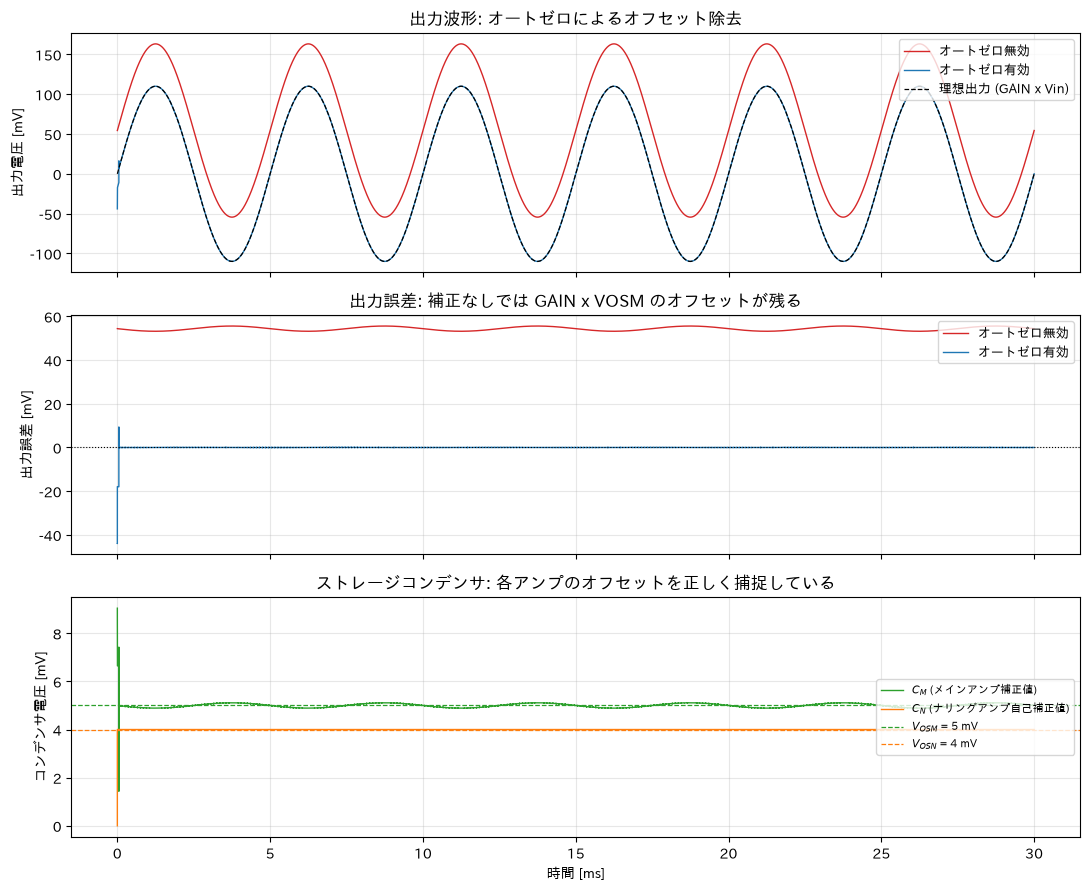

C_M 最終値 = 4.9987 mV  (VOSM = 5.0 mV)
C_N 最終値 = 4.0000 mV  (VOSN = 4.0 mV)


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

t_off = analysis_off.time.as_ndarray() * 1e3
t_on = analysis_on.time.as_ndarray() * 1e3

# --- (1) 出力波形の比較 ---
ax = axes[0]
ax.plot(t_off, analysis_off["vout"].as_ndarray() * 1e3,
        label="オートゼロ無効", color="tab:red", lw=1.0)
ax.plot(t_on, analysis_on["vout"].as_ndarray() * 1e3,
        label="オートゼロ有効", color="tab:blue", lw=1.0)
ax.plot(t_on, GAIN * analysis_on["vin"].as_ndarray() * 1e3,
        label="理想出力 (GAIN x Vin)", color="k", ls="--", lw=0.9)
ax.set_ylabel("出力電圧 [mV]")
ax.set_title("出力波形: オートゼロによるオフセット除去")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)

# --- (2) 誤差 (出力 - 理想出力) ---
ax = axes[1]
ax.plot(t_off, (analysis_off["vout"].as_ndarray()
                - GAIN * analysis_off["vin"].as_ndarray()) * 1e3,
        label="オートゼロ無効", color="tab:red", lw=1.0)
ax.plot(t_on, (analysis_on["vout"].as_ndarray()
               - GAIN * analysis_on["vin"].as_ndarray()) * 1e3,
        label="オートゼロ有効", color="tab:blue", lw=1.0)
ax.axhline(0, color="k", lw=0.8, ls=":")
ax.set_ylabel("出力誤差 [mV]")
ax.set_title("出力誤差: 補正なしでは GAIN x VOSM のオフセットが残る")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)

# --- (3) ストレージコンデンサの電圧 ---
ax = axes[2]
ax.plot(t_on, analysis_on["cm"].as_ndarray() * 1e3,
        label="$C_M$ (メインアンプ補正値)", color="tab:green", lw=1.0)
ax.plot(t_on, analysis_on["cn"].as_ndarray() * 1e3,
        label="$C_N$ (ナリングアンプ自己補正値)", color="tab:orange", lw=1.0)
ax.axhline(VOSM * 1e3, color="tab:green", ls="--", lw=0.9,
           label=f"$V_{{OSM}}$ = {VOSM*1e3:.0f} mV")
ax.axhline(VOSN * 1e3, color="tab:orange", ls="--", lw=0.9,
           label=f"$V_{{OSN}}$ = {VOSN*1e3:.0f} mV")
ax.set_xlabel("時間 [ms]")
ax.set_ylabel("コンデンサ電圧 [mV]")
ax.set_title("ストレージコンデンサ: 各アンプのオフセットを正しく捕捉している")
ax.legend(loc="center right", fontsize=8)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

print(f"C_M 最終値 = {analysis_on['cm'].as_ndarray()[-1]*1e3:.4f} mV  (VOSM = {VOSM*1e3:.1f} mV)")
print(f"C_N 最終値 = {analysis_on['cn'].as_ndarray()[-1]*1e3:.4f} mV  (VOSN = {VOSN*1e3:.1f} mV)")

### オートゼロクロックとストレージ電圧の詳細

定常状態の数周期を拡大し、2 相動作の様子を確認する。
$\phi$ が H の期間に $C_N$ が、$\overline{\phi}$ が H の期間に $C_M$ が
それぞれ更新され、それ以外の期間は値を保持していることがわかる。

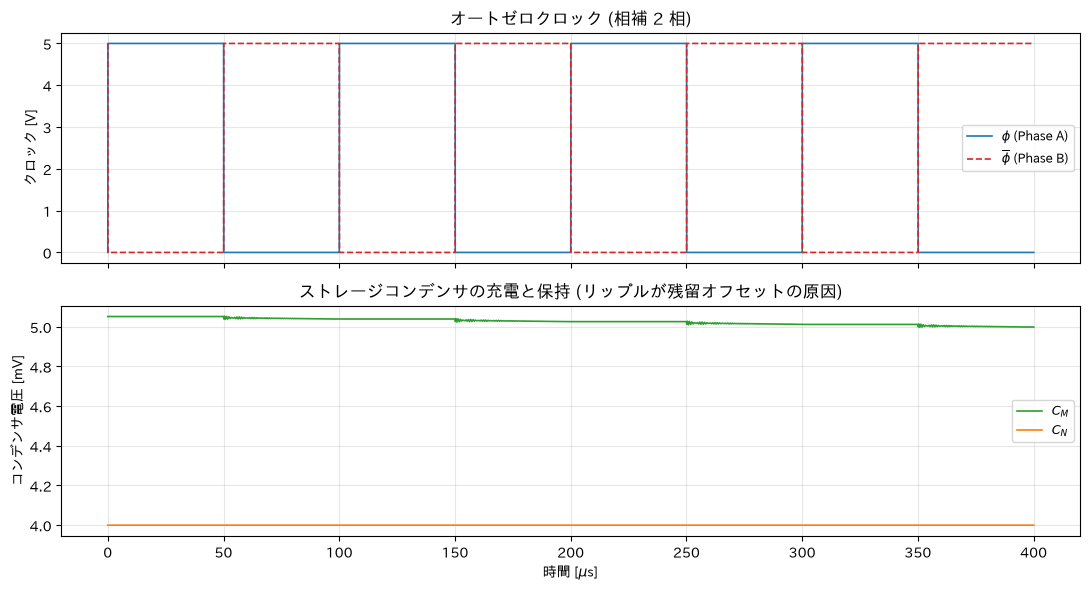

C_M のリップル (peak-to-peak) = 56.44 uV


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

t = analysis_on.time.as_ndarray()
# 定常状態の後半 4 オートゼロ周期を抽出
window = (t > t[-1] - 4 * TAZ)
t_us = (t[window] - t[window][0]) * 1e6

axes[0].plot(t_us, analysis_on["phi"].as_ndarray()[window],
             label=r"$\phi$ (Phase A)", color="tab:blue", lw=1.2)
axes[0].plot(t_us, analysis_on["phib"].as_ndarray()[window],
             label=r"$\overline{\phi}$ (Phase B)", color="tab:red", lw=1.2, ls="--")
axes[0].set_ylabel("クロック [V]")
axes[0].set_title("オートゼロクロック (相補 2 相)")
axes[0].legend(loc="center right", fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].plot(t_us, analysis_on["cm"].as_ndarray()[window] * 1e3,
             label="$C_M$", color="tab:green", lw=1.2)
axes[1].plot(t_us, analysis_on["cn"].as_ndarray()[window] * 1e3,
             label="$C_N$", color="tab:orange", lw=1.2)
axes[1].set_xlabel(r"時間 [$\mu$s]")
axes[1].set_ylabel("コンデンサ電圧 [mV]")
axes[1].set_title("ストレージコンデンサの充電と保持 (リップルが残留オフセットの原因)")
axes[1].legend(loc="center right", fontsize=9)
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

cm_steady = analysis_on["cm"].as_ndarray()[window]
print(f"C_M のリップル (peak-to-peak) = {np.ptp(cm_steady)*1e6:.2f} uV")

## 5. オフセット依存性の検証

$V_{OSM}$ と $V_{OSN}$ をさまざまな値に振り、オートゼロが
オフセットの符号・大きさによらず機能することを確認する。

In [7]:
conditions = [
    (5e-3, 4e-3),
    (-3e-3, 2e-3),
    (10e-3, -5e-3),
    (1e-3, 1e-3),
    (0.0, 0.0),
]

print(f"{'VOSM[mV]':>9} {'VOSN[mV]':>9} | {'補正なし[mV]':>13} {'補正あり[uV]':>13}")
print("-" * 52)

results = []
for vosm, vosn in conditions:
    # グローバルパラメータを一時的に差し替えて再構築する
    globals()["VOSM"], globals()["VOSN"] = vosm, vosn
    off = output_offset(simulate(auto_zero=False))
    on = output_offset(simulate(auto_zero=True))
    results.append((vosm, vosn, off, on))
    print(f"{vosm*1e3:9.1f} {vosn*1e3:9.1f} | {off*1e3:13.4f} {on*1e6:13.2f}")

# パラメータを元に戻す
globals()["VOSM"], globals()["VOSN"] = 5e-3, 4e-3

Using SPARSE 1.3 as Direct Linear Solver
Note: vphib: dc value used for op instead of transient time=0 value.
Using SPARSE 1.3 as Direct Linear Solver
Note: vphib: dc value used for op instead of transient time=0 value.


 VOSM[mV]  VOSN[mV] |      補正なし[mV]      補正あり[uV]
----------------------------------------------------


Using SPARSE 1.3 as Direct Linear Solver
Note: vphib: dc value used for op instead of transient time=0 value.
Using SPARSE 1.3 as Direct Linear Solver
Note: vphib: dc value used for op instead of transient time=0 value.


      5.0       4.0 |       54.4015          0.47


Using SPARSE 1.3 as Direct Linear Solver
Note: vphib: dc value used for op instead of transient time=0 value.
Using SPARSE 1.3 as Direct Linear Solver
Note: vphib: dc value used for op instead of transient time=0 value.


     -3.0       2.0 |      -32.6410          0.17


Using SPARSE 1.3 as Direct Linear Solver
Note: vphib: dc value used for op instead of transient time=0 value.
Using SPARSE 1.3 as Direct Linear Solver
Note: vphib: dc value used for op instead of transient time=0 value.


     10.0      -5.0 |      108.8031         -0.39


Using SPARSE 1.3 as Direct Linear Solver
Note: vphib: dc value used for op instead of transient time=0 value.
Using SPARSE 1.3 as Direct Linear Solver
Note: vphib: dc value used for op instead of transient time=0 value.


      1.0       1.0 |       10.8802          0.12
      0.0       0.0 |       -0.0001          0.00


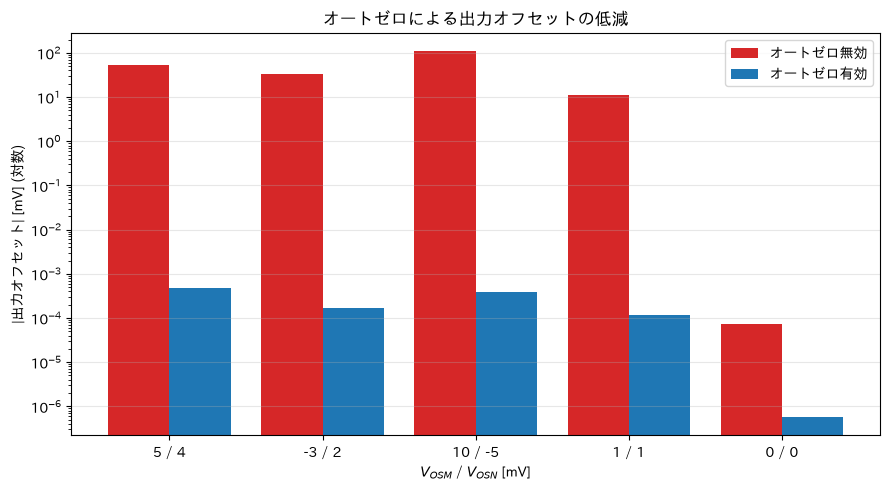

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

labels = [f"{v1*1e3:.0f} / {v2*1e3:.0f}" for v1, v2, _, _ in results]
x = np.arange(len(results))
off_vals = [abs(r[2]) * 1e3 for r in results]
on_vals = [max(abs(r[3]) * 1e3, 1e-7) for r in results]

ax.bar(x - 0.2, off_vals, 0.4, label="オートゼロ無効", color="tab:red")
ax.bar(x + 0.2, on_vals, 0.4, label="オートゼロ有効", color="tab:blue")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel("$V_{OSM}$ / $V_{OSN}$ [mV]")
ax.set_ylabel("|出力オフセット| [mV] (対数)")
ax.set_title("オートゼロによる出力オフセットの低減")
ax.legend()
ax.grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

## 6. schemdraw による回路図

オートゼロアンプのブロック構成を描画する。

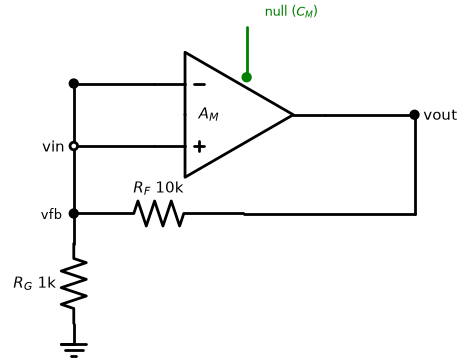

In [9]:
import schemdraw
import schemdraw.elements as elm

# schemdraw は matplotlib とは別にフォントを扱うため、
# 図中のラベルは ASCII / 数式で記述する (日本語の説明は本文側に記載)。

with schemdraw.Drawing() as d:
    d.config(fontsize=11)

    # メインアンプ: vin は非反転入力 (in2)、vfb は反転入力 (in1)
    main = elm.Opamp(leads=True).label("$A_M$", loc="center", ofst=(-0.6, 0))
    d += main

    d += elm.Line().left().length(1.6).at(main.in2)
    d += elm.Dot(open=True).label("vin", loc="left")

    d += elm.Line().right().length(1.8).at(main.out)
    out = elm.Dot().label("vout", loc="right")
    d += out

    # 反転入力から左へ引き出し、下へ降ろして vfb ノードを作る
    d += elm.Line().left().length(1.6).at(main.in1)
    fbtop = elm.Dot()
    d += fbtop
    d += elm.Line().down().length(2.6).at(fbtop.center)
    fb = elm.Dot()
    d += fb
    d += elm.Label().label("vfb", fontsize=9).at((fb.center[0] - 0.55, fb.center[1] + 0.1))

    # vfb -> RG -> GND
    d += elm.Line().down().length(0.6).at(fb.center)
    d += elm.Resistor().down().length(1.6).label("$R_G$ 1k")
    d += elm.Ground()

    # vfb -> RF -> vout
    d += elm.Resistor().right().length(3.4).at(fb.center).label("$R_F$ 10k")
    d += elm.Line().right().to((out.center[0], fb.center[1]))
    d += elm.Line().up().to(out.center)

    # null 端子 (C_M からの補正入力)
    null_x = main.center[0] + 0.15
    null_y = main.center[1] + 0.75
    d += elm.Dot().at((null_x, null_y)).color("green")
    d += elm.Line().at((null_x, null_y)).up().length(1.0).color("green")
    d += elm.Label().label("null ($C_M$)", color="green", fontsize=9).at(
        (null_x + 1.0, null_y + 1.2))

### ナリングアンプと 2 相スイッチ

ナリングアンプ $A_N$ の出力は、クロックに応じて 2 つのストレージコンデンサに振り分けられる。

- $\phi$ (青): Phase A — 入力を短絡し、自身のオフセットを $C_N$ に取得
- $\overline{\phi}$ (赤): Phase B — メインアンプの誤差を測定し $C_M$ に蓄積

$C_M$ の電圧がメインアンプの null 端子へ送られ、オフセットを打ち消す。

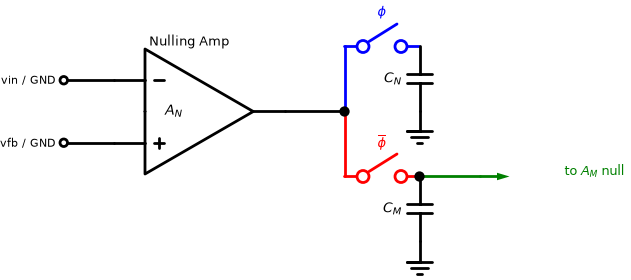

In [10]:
with schemdraw.Drawing() as d:
    d.config(fontsize=10)

    # ===== ナリングアンプ =====
    nul = elm.Opamp(leads=True).label("$A_N$", loc="center", ofst=(-0.5, 0))
    d += nul
    d += elm.Label().label("Nulling Amp", fontsize=9).at(
        (nul.center[0] - 0.3, nul.center[1] + 1.3))

    # 入力: Phase A では短絡(GND)、Phase B では (vin, vfb)
    d += elm.Line().left().length(1.0).at(nul.in1)
    d += elm.Dot(open=True).label("vin / GND", loc="left", fontsize=8)
    d += elm.Line().left().length(1.0).at(nul.in2)
    d += elm.Dot(open=True).label("vfb / GND", loc="left", fontsize=8)

    # 出力から 2 つのストレージへ分岐
    d += elm.Line().right().length(1.2).at(nul.out)
    node = elm.Dot()
    d += node

    # Phase A -> C_N
    d += elm.Line().up().length(1.3).at(node.center).color("blue")
    d += elm.Switch().right().length(1.5).color("blue").label(r"$\phi$", fontsize=9)
    d += elm.Capacitor().down().length(1.3).label("$C_N$")
    d += elm.Ground()

    # Phase B -> C_M -> null 端子
    d += elm.Line().down().length(1.3).at(node.center).color("red")
    d += elm.Switch().right().length(1.5).color("red").label(
        r"$\overline{\phi}$", fontsize=9)
    cm = elm.Dot()
    d += cm
    d += elm.Capacitor().down().length(1.3).at(cm.center).label("$C_M$")
    d += elm.Ground()

    d += elm.Line().right().length(1.2).at(cm.center).color("green")
    d += elm.Arrow().right().length(0.6).color("green")
    d += elm.Label().label("to $A_M$ null", color="green", fontsize=9).at(
        (cm.center[0] + 3.4, cm.center[1]))

## 7. まとめ

| 項目 | 値 |
|---|---|
| クローズドループゲイン | 11 V/V |
| メインアンプのオフセット $V_{OSM}$ | 5 mV |
| ナリングアンプのオフセット $V_{OSN}$ | 4 mV |
| 出力オフセット (オートゼロ無効) | 約 54.4 mV |
| 出力オフセット (オートゼロ有効) | 約 0.5 µV |
| オフセット低減比 | 約 $10^5$ 倍 |

### 設計上の要点

1. **観測節点の選択**
   ナリングアンプはメインアンプの**外部入力ピン** (`vin`, `vfb`) 間を観測する必要がある。
   オフセット源より内側の節点 (`vinp`) を観測すると $V_{OSM}$ が相殺されて
   検出できなくなり、補正が効かなくなる。

2. **ストレージ時定数**
   $R_O \cdot C$ がオートゼロの半周期より十分短くないと、1 フェーズ内で
   コンデンサが整定せず補正が追従しない。本設計では
   $R_O C = 10\ \mu s$ に対しフェーズ幅 $50\ \mu s$ としている。

3. **null 端子の帰還極性**
   null 入力段の向きを誤ると正帰還となり、出力が電源レールへ張り付いて
   解析が発散する。負帰還となる向きに接続する必要がある。

4. **残留オフセットの要因**
   ストレージコンデンサのリップル (約 75 µV) と有限なループゲインが
   残留オフセットを決める。実際の IC ではこれに加えて
   スイッチのチャージインジェクションやクロックフィードスルーが効く。